<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Exploratory Data Analysis**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis or EDA. 


## Objectives


In this lab, you will perform the following:


- Examine the structure of a dataset.

- Handle missing values effectively.

- Conduct summary statistics on key columns.

- Analyze employment status, job satisfaction, programming language usage, and trends in remote work.


## Hands on Lab


#### Step 1: Install and Import Libraries


Install the necessary libraries for data manipulation and visualization.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Load and Preview the Dataset
Load the dataset from the provided URL. Use df.head() to display the first few rows to get an overview of the structure.


In [ ]:
# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataset
df.head()

#### Step 3: Handling Missing Data


Identify and manage missing values in critical columns such as `Employment`, `JobSat`, and `RemoteWork`. Implement a strategy to fill or drop these values, depending on the significance of the missing data.


In [ ]:
## Write your code here
df[['Employment', 'JobSat', 'RemoteWork', 'Country']].isna().sum()

Employment        0
JobSat        36311
RemoteWork    10631
Country        6507
dtype: int64

In [ ]:
df[['JobSat', 'RemoteWork']].dtypes

JobSat        float64
RemoteWork     object
dtype: object

In [ ]:
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mean())
df['JobSat']

0        6.935041
1        6.935041
2        6.935041
3        6.935041
4        6.935041
           ...   
65432    6.935041
65433    6.935041
65434    6.935041
65435    6.935041
65436    6.935041
Name: JobSat, Length: 65437, dtype: float64

In [ ]:
df['RemoteWork'] = df['RemoteWork'].ffill()
df['RemoteWork']

0                                      Remote
1                                      Remote
2                                      Remote
3                                      Remote
4                                      Remote
                         ...                 
65432                                  Remote
65433                                  Remote
65434                               In-person
65435    Hybrid (some remote, some in-person)
65436    Hybrid (some remote, some in-person)
Name: RemoteWork, Length: 65437, dtype: object

#### Step 4: Analysis of Experience and Job Satisfaction


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`). Summarize `YearsCodePro` and calculate median satisfaction scores based on experience ranges.

- Create experience ranges for `YearsCodePro` (e.g., `0-5`, `5-10`, `10-20`, `>20` years).

- Calculate the median `JobSat` for each range.

- Visualize the relationship using a bar plot or similar visualization.


In [ ]:
## Write your code here
df['YearsCodePro'].isna().sum()

np.int64(13827)

In [ ]:
df['YearsCodePro'].unique()

NameError: name 'df' is not defined

In [ ]:
import numpy as np

df['YearsCodePro_num'] = (
    df['YearsCodePro']
    .replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    .astype(float)
)


In [ ]:
bins = [0, 2, 5, 10, 100]  
labels = ['0-2 (Junior)', '2-5 (Mid-level)', '5-10 (Senior)', '>10 (Expert)']

df['ExperienceRange'] = pd.cut(
    df['YearsCodePro_num'], 
    bins=bins, 
    labels=labels, 
    right=False
)
df['ExperienceRange']

0          5-10 (Senior)
1           >10 (Expert)
2           >10 (Expert)
3          5-10 (Senior)
4          5-10 (Senior)
              ...       
65432    2-5 (Mid-level)
65433      5-10 (Senior)
65434      5-10 (Senior)
65435    2-5 (Mid-level)
65436      5-10 (Senior)
Name: ExperienceRange, Length: 65437, dtype: category
Categories (4, object): ['0-2 (Junior)' < '2-5 (Mid-level)' < '5-10 (Senior)' < '>10 (Expert)']

In [ ]:
median_job_sat = df.groupby('ExperienceRange')['JobSat'].median()
median_job_sat

C:\Users\HP\AppData\Local\Temp\ipykernel_8256\2881820601.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_job_sat = df.groupby('ExperienceRange')['JobSat'].median()


ExperienceRange
0-2 (Junior)       6.935041
2-5 (Mid-level)    6.935041
5-10 (Senior)      6.935041
>10 (Expert)       6.935041
Name: JobSat, dtype: float64

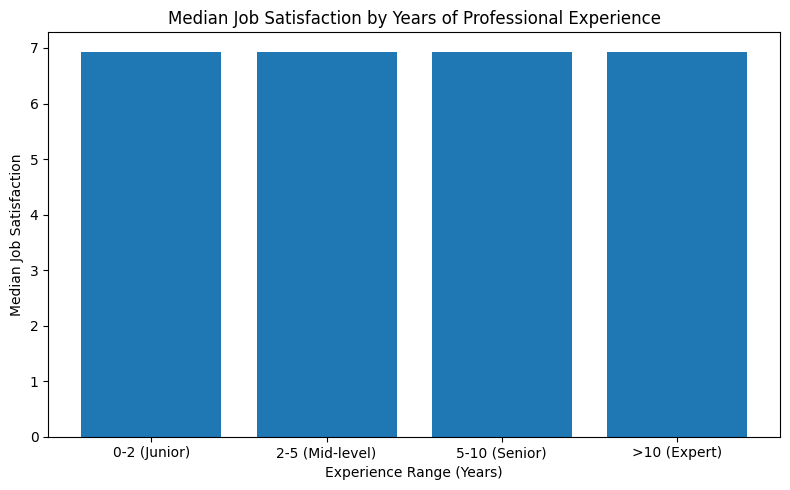

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(median_job_sat.index.astype(str), median_job_sat.values)

plt.title('Median Job Satisfaction by Years of Professional Experience')
plt.xlabel('Experience Range (Years)')
plt.ylabel('Median Job Satisfaction')

plt.tight_layout()
plt.show()

#### Step 5: Visualize Job Satisfaction


Use a count plot to show the distribution of `JobSat` values. This provides insights into the overall satisfaction levels of respondents.


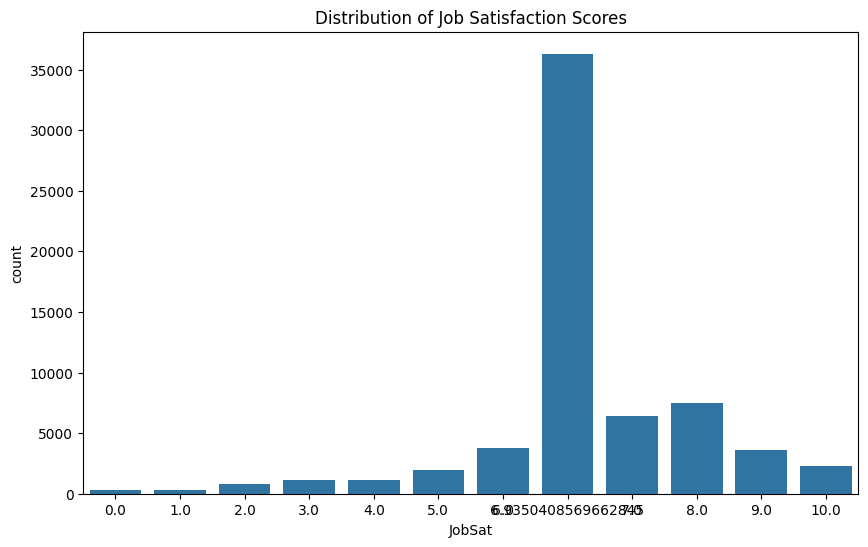

In [ ]:
## Write your code here
plt.figure(figsize=(10, 6))
sns.countplot(x='JobSat', data=df, order=sorted(df['JobSat'].dropna().unique()))
plt.title('Distribution of Job Satisfaction Scores')
plt.show()

#### Step 6: Analyzing Remote Work Preferences by Job Role


Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others.

- Use a count plot to show remote work distribution.

- Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.


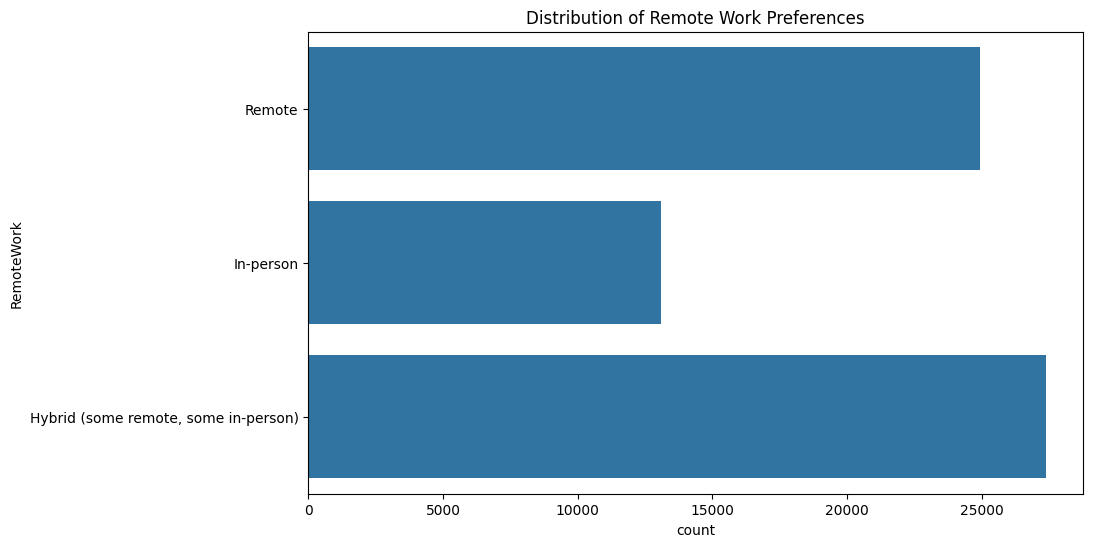

In [ ]:
## Write your code here
plt.figure(figsize=(10,6))
sns.countplot(y='RemoteWork', data=df) 
plt.title('Distribution of Remote Work Preferences')
plt.show()

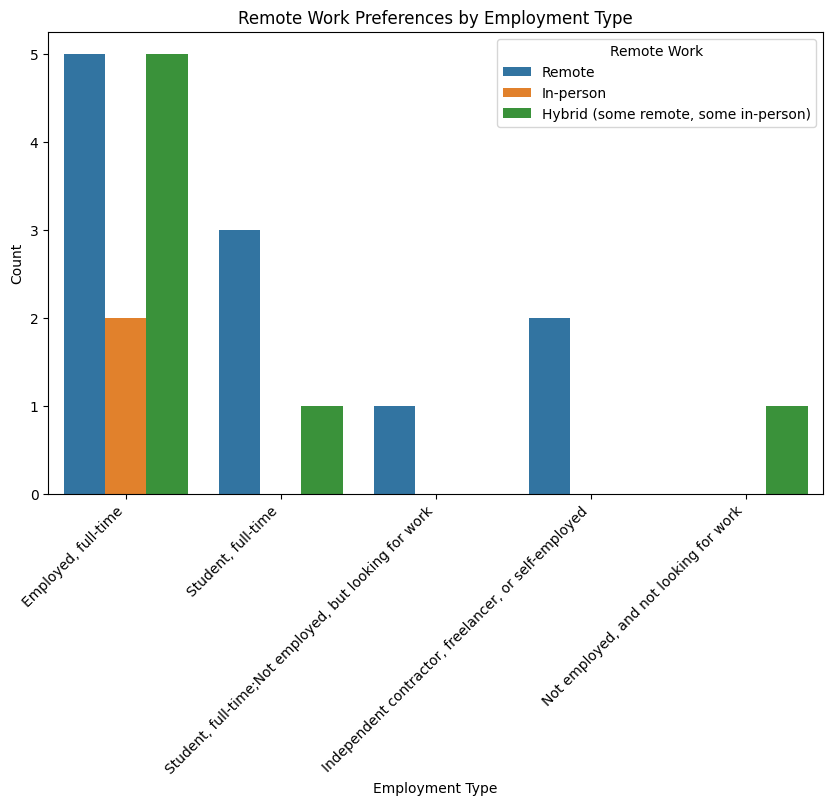

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Employment', hue='RemoteWork', data=df.head(20))
plt.title('Remote Work Preferences by Employment Type')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.legend(title='Remote Work')
plt.show()

In [ ]:
remote_by_employment = pd.crosstab(df['RemoteWork'], df['Employment'])
remote_by_employment

Employment,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Retired","Employed, full-time;Not employed, and not looking for work","Employed, full-time;Not employed, but looking for work","Employed, full-time;Not employed, but looking for work;Employed, part-time","Employed, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed","Employed, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Not employed, but looking for work;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Not employed, but looking for work;Student, part-time","Employed, full-time;Retired","Employed, full-time;Student, full-time","Employed, full-time;Student, full-time;Employed, part-time","Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time;Retired","Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Student, part-time;Retired","Employed, full-time;Student, full-time;Not employed, but looking for work","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time;Employed, part-time","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time;Employed, part-time;Retired","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Employed, full-time;Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time;Retired","Employed, full-time;Student, full-time;Not employed, but looking for work;Student, part-time","Employed, full-time;Student, full-time;Not employed, but looking for work;Student, part-time;Employed, part-time","Employed, full-t

#### Step 7: Analyzing Programming Language Trends by Region


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

- Filter data by country or region.

- Visualize the top programming languages by region with a bar plot or heatmap.


In [ ]:
## Write your code here
df['LanguageHaveWorkedWith'].head()

0                                                  NaN
1    Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2                                                   C#
3    C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...
4              C++;HTML/CSS;JavaScript;Lua;Python;Rust
Name: LanguageHaveWorkedWith, dtype: object

In [ ]:
# Split languages into lists
df['LanguagesList'] = df['LanguageHaveWorkedWith'].str.split(';')
df['LanguagesList']

0                                                      NaN
1        [Bash/Shell (all shells), Go, HTML/CSS, Java, ...
2                                                     [C#]
3        [C, C++, HTML/CSS, Java, JavaScript, PHP, Powe...
4           [C++, HTML/CSS, JavaScript, Lua, Python, Rust]
                               ...                        
65432                                                  NaN
65433                                                  NaN
65434                                                  NaN
65435    [C, C++, Go, Lua, Objective-C, Python, Rust, SQL]
65436    [C, HTML/CSS, Java, JavaScript, PHP, Python, T...
Name: LanguagesList, Length: 65437, dtype: object

In [ ]:
# Each language gets its own row
df = df.explode('LanguagesList')
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ExperienceRange,LanguagesList
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.935041,5-10 (Senior),NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17.0,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,

In [ ]:
df = df[df['Country'] == 'Kenya']
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ExperienceRange,LanguagesList
2016,2017,I am a developer by profession,18-24 years old,"Independent contractor, freelancer, or self-em...","Hybrid (some remote, some in-person)",Apples,Bootstrapping a business,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Books;Written Tu...,User guides or README files found in the sourc...,6,4.0,"Developer, back-end",2 to 9 employees,I have a great deal of influence,Start a free trial;Ask developers I know/work ...,Out-of-the-box is ready to go with little need...,APIs;Customization;Integrated developer commun...,Kenya,KES\tKenyan shilling,NaN,Bash/Shell (all shells);Python,Bash/Shell (all shells);Python,Bash/Shell (all shells);Python,PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Microsoft Azure,Heroku;Microsoft Azure,Heroku;Microsoft Azure,Django,Django,Django,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Kubernetes;Pip,Docker;Kubernetes;Pip,Docker;Kubernetes;Pip,Visual Studio Code,Visual Studio Code,Visual Studio Code,Ubuntu,Ubuntu,Azure Devops;Basecamp,Azure Devops;Basecamp,Azure Devops;Basecamp,Telegram;Zoom,Telegram,Telegram,ChatGPT;Claude;Google Gemini;Quora Poe;Visual ...,ChatGPT;Claude;Google Gemini;Visual Studio Int...,ChatGPT;Claude;Google Gemini;Visual Studio Int...,Stack Overflow;Stack Exchange,A few times per month or weekly,Yes,A few times per month or weekly,Quickly finding code solutions;Engage with com...,Neutral,Yes,Very favorable,Increase productivity;Greater efficiency;Speed...,Somewhat trust,"Good, but not great at handling complex tasks",Project planning;Writing code;Debugging and ge...,Learning about a codebase;Documenting code;Tes...,NaN,Project planning;Writing code;Debugging and ge...,NaN,NaN,NaN,NaN,No,Circulating misinformation or disinformation;B...,"AI tools lack context of codebase, internal a...",No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,6.935041,2-5 (Mid-level),Bash/Shell (all shells)
2016,2017,I am a developer by profession,18-24 years old,"Independent contractor, freelancer, or self-em...",

In [ ]:
language_counts = df['LanguagesList'].value_counts().head(10)
language_counts

LanguagesList
JavaScript                 128
Python                     105
HTML/CSS                   104
SQL                         97
TypeScript                  74
Java                        54
PHP                         49
C                           39
Bash/Shell (all shells)     38
C#                          34
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_8256\1295583870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis')


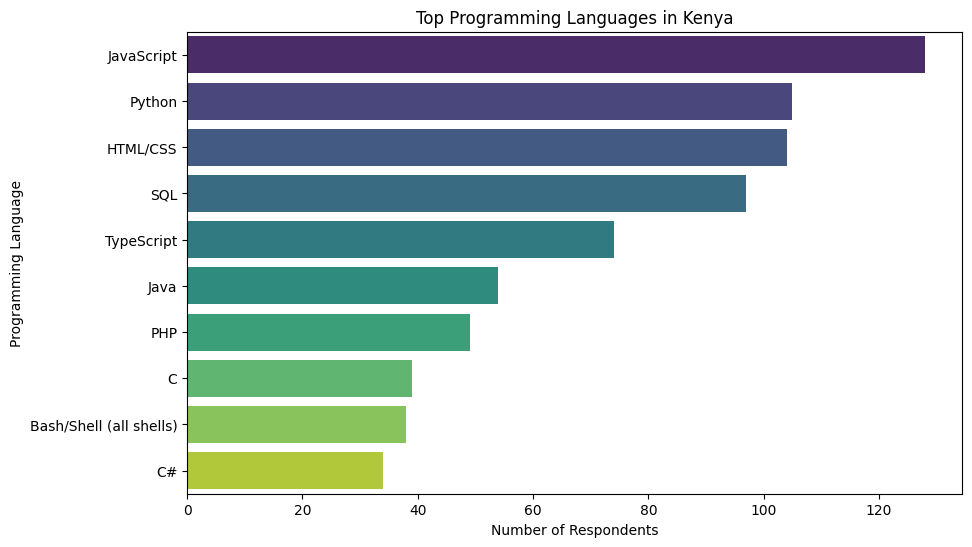

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis')
plt.title('Top Programming Languages in Kenya')
plt.xlabel('Number of Respondents')
plt.ylabel('Programming Language')
plt.show()

#### Step 8: Correlation Between Experience and Satisfaction


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSatPoints_1`). Use a scatter plot to visualize this relationship.


In [ ]:
## Write your code here
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['JobSatPoints_1'] = pd.to_numeric(df['JobSatPoints_1'], errors='coerce')

In [ ]:
df_scatter = df.dropna(subset=['YearsCodePro', 'JobSatPoints_1'])

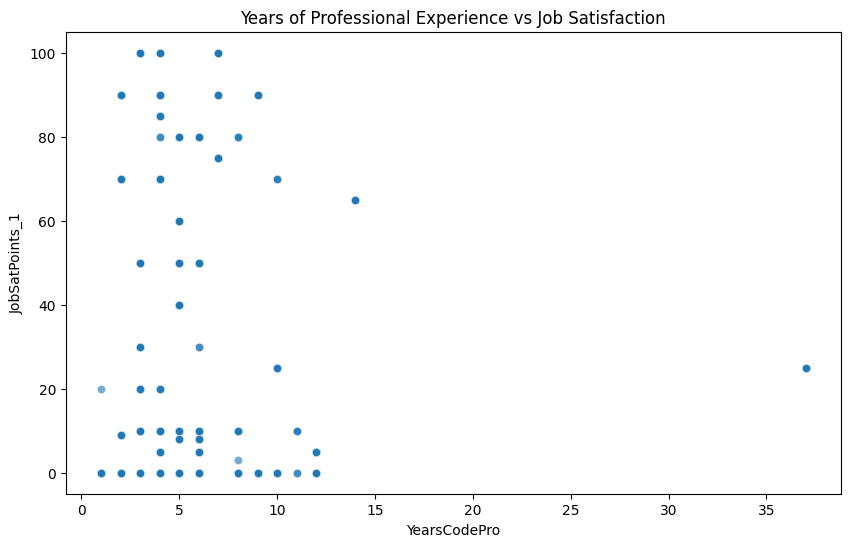

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='YearsCodePro', y='JobSatPoints_1', data=df_scatter, alpha=0.6)
plt.title('Years of Professional Experience vs Job Satisfaction')
plt.show()

#### Step 9: Educational Background and Employment Type


Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.


In [ ]:
## Write your code here
pd.crosstab(df['EdLevel'], df['Employment'])

Employment,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Student, full-time","Employed, full-time;Student, part-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Independent contractor, freelancer, or self-employed;Employed, part-time","Independent contractor, freelancer, or self-employed;Student, part-time;Employed, part-time","Not employed, and not looking for work","Not employed, but looking for work","Not employed, but looking for work;Independent contractor, freelancer, or self-employed","Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Employed, part-time","Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Student, part-time","Not employed, but looking for work;Not employed, and not looking for work","Not employed, but looking for work;Student, part-time","Not employed, but looking for work;Student, part-time;Employed, part-time","Student, full-time","Student, full-time;Independent contractor, freelancer, or self-employed","Student, full-time;Not employed, and not looking for work","Student, full-time;Not employed, but looking for work","Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed","Student, full-time;Student, part-time","Student, part-time","Student, part-time;Employed, part-time"
EdLevel,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Associate degree (A.A., A.S., etc.)",6,0,0,10,0,0,0,0,8,0,0,0,1,0,0,0,0,5,0,0,0,0,0,0,0,1,0
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",192,4,39,6,9,13,34,10,134,15,3,0,60,29,2,10,0,15,4,27,12,26,11,18,7,13,2
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",19,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Primary/elementary school,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",0,0,0,0,0,0,7,0,0,0,0,7,38,0,0,0,0,0,0,39,0,0,0,0,0,1,8
Some college/university study without earning a degree,39,0,0,0,0,6,8,0,13,6,0,1,23,0,0,0,2,6,0,4,0,0,8,0,0,2,6
Something else,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,20,0


#### Step 10: Save the Cleaned and Analyzed Dataset


After your analysis, save the modified dataset for further use or sharing.


In [ ]:
## Write your code here
df.to_csv("Final_EDA.csv", index=False)

<h2>Summary</h2>


In this revised lab, you:

- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.


Copyright © IBM Corporation. All rights reserved.
